### *Importing required packages*

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
pd.options.mode.chained_assignment = None

In [39]:
# creating dictionary to store data_frames
d={}
progress=[]

### *Extracting past 3 quaters of data*
- *created two functions one to take folder address*
- *other one to extract and combine csv files present in each folder*

In [706]:
def combine(z,name):
    d[name]=pd.DataFrame()
    print('creating data_frame......')
    for i in z:
        df=pd.read_csv(i)
        d[name]=d[name].append(df,ignore_index=True)
    print('done')

In [25]:
def get(i,name):
    z=glob.glob(i+'/*')
    combine(z,name)

In [ ]:
start=time.time()
f=glob.glob('C:/Users/Admin/Desktop/cyclists/excel_data/*')
for i in f:
    get(i,i[-12:])
end=time.time()
print('{} seconds taken to complete the process'.format(end-start))

In [4]:
data_2022_q1=pd.DataFrame()
path=glob.glob('C:/Users/Admin/Desktop/cyclists/excel_data/data_2022_q1/*')
for i in path:
    df=pd.read_csv(i)
    data_2022_q1=data_2022_q1.append(df,ignore_index=True)
    print('done')
data_2022_q1.shape

done
done
done
done
done
done


(2278732, 13)

### *Checking for inconsistencies and cleaning data*

In [6]:
data_1=d['data_2022_Q2'].copy()
data_2=d['data_2023_Q1'].copy()

In [8]:
progress.append((data_1.shape,data_2.shape))

In [9]:
progress

[((3388985, 13), (2390459, 13))]

In [10]:
#checking for validity of data
print(data_1['started_at'].max(),data_1.started_at.min())
print(data_2.started_at.max(),data_2.started_at.min())

2022-12-31 23:59:26 2022-07-01 00:00:01
2023-06-30 23:59:56 2023-01-01 00:01:58


In [11]:
# checking for data_types
data_1.dtypes

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

In [12]:
data_1['started_at']=pd.to_datetime(data_1['started_at'])
data_1['ended_at']=pd.to_datetime(data_1['ended_at'])

In [13]:
data_2['started_at']=pd.to_datetime(data_2['started_at'])
data_2['ended_at']=pd.to_datetime(data_2['ended_at'])

In [14]:
data_2.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object

### *checking for duplicates*

In [15]:
print(data_1['ride_id'].value_counts().max())
data_2['ride_id'].value_counts().max()

1


1

In [16]:
# creating time_diff to find average time per ride
data_1['diff']=(data_1['ended_at']-data_1['started_at'])/pd.Timedelta(hours=1)
data_2['diff']=(data_2['ended_at']-data_2['started_at'])/pd.Timedelta(hours=1)

In [17]:
print(data_1['diff'].max(),data_1['diff'].min())
data_2['diff'].max(),data_2['diff'].min()

689.7875 -172.55583333333334


(560.0622222222222, -1.0041666666666667)

### *Removing data with negative ride_time*

In [18]:
index_1=data_1[data_1['diff']<=0].index
index_2=data_2[data_2['diff']<=0].index
data_1.drop(index_1,inplace=True)
data_2.drop(index_2,inplace=True)

In [20]:
progress.append((data_1.shape,data_2.shape))

In [21]:
progress

[((3388985, 13), (2390459, 13)), ((3388627, 14), (2390243, 14))]

In [22]:
# rechecking
data_1['diff'].min(),data_2['diff'].min()

(0.0002777777777777778, 0.0002777777777777778)

In [23]:
# checking for member,id null values
print(data_1['member_casual'].isnull().any(),data_1['ride_id'].isnull().any())
data_2['member_casual'].isnull().any(),data_2['ride_id'].isnull().any()

False False


(False, False)

### *Checking and removing casual_ride_time which are greater than 24hrs*

In [24]:
index=data_1[(data_1['diff']>26) & (data_1['member_casual']=='casual')].index
data_1.drop(index,inplace=True)

In [27]:
index_=data_2[(data_2['diff']>26) & (data_2['member_casual']=='casual')].index
data_2.drop(index_,inplace=True)

In [28]:
progress.append((data_1.shape,data_2.shape))

In [29]:
progress

[((3388985, 13), (2390459, 13)),
 ((3388627, 14), (2390243, 14)),
 ((3387707, 14), (2389663, 14))]

In [34]:
print(data_1['diff'].min(),data_1['diff'].max())
print(data_2['diff'].min(),data_2['diff'].max())

0.0002777777777777778 25.8075
0.0002777777777777778 25.99888888888889


### *Importing data*

In [2]:
data_0=pd.read_csv('C:/Users/Admin/Desktop/cyclists/excel_data/data_2022_q1.csv')

In [3]:
data_1=pd.read_csv('C:/Users/Admin/Desktop/cyclists/excel_data/data_2022_q2.csv')
data_2=pd.read_csv('C:/Users/Admin/Desktop/cyclists/excel_data/data_2023_q1.csv')

In [4]:
data_0['started_at']=pd.to_datetime(data_0['started_at'])
data_0['ended_at']=pd.to_datetime(data_0['ended_at'])

In [47]:
data_1['started_at']=pd.to_datetime(data_1['started_at'])
data_1['ended_at']=pd.to_datetime(data_1['ended_at'])
data_2['started_at']=pd.to_datetime(data_2['started_at'])
data_2['ended_at']=pd.to_datetime(data_2['ended_at'])

### *Checking popular days and months among riders*

In [138]:
check_0=data_0[['ride_id','started_at','member_casual','diff']]
check_1=data_1[['ride_id','started_at','member_casual','diff']]
check_2=data_2[['ride_id','started_at','member_casual','diff']]

In [139]:
req_data=pd.concat([check_0,check_1,check_2])

In [150]:
plt_data=req_data[['started_at','member_casual']]

In [151]:
plt_data=plt_data.assign(month=plt_data['started_at'].dt.strftime('%y-%m'))

<AxesSubplot:xlabel='month'>

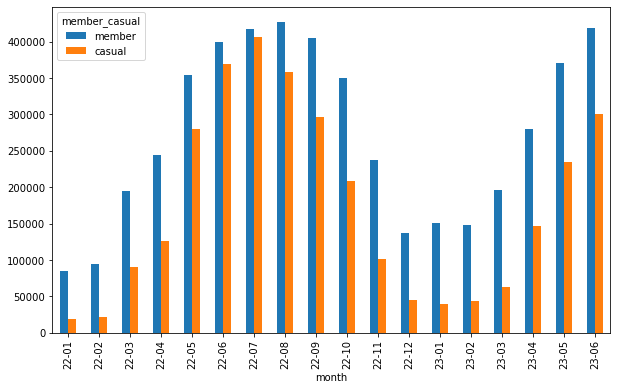

In [152]:
plt_data.groupby(['month','member_casual']).member_casual.count().unstack().reset_index().plot.bar(x='month',y=['member','casual'],figsize=[10,6])

In [173]:
del plt_data

In [174]:
plt_data=req_data[['started_at','member_casual']]

In [175]:
plt_data=plt_data.assign(day=plt_data['started_at'].dt.strftime('%A'))

<AxesSubplot:xlabel='day'>

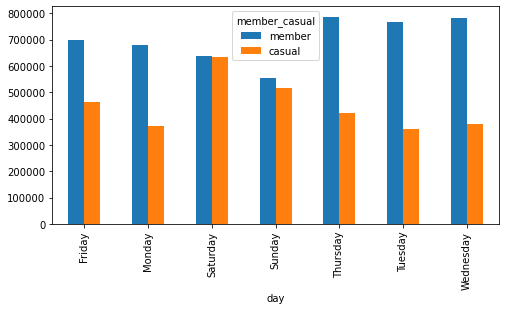

In [177]:
plt_data.groupby(['day','member_casual']).member_casual.count().unstack().reset_index().plot.bar(x='day',y=['member','casual'],figsize=[8,4])

In [178]:
del plt_data

### *preffered minutes per ride*

In [315]:
# function for pie plot
def pie_plot(data,labels):
    fig,ax=plt.subplots()
    patches,texts,pcts=ax.pie(data,labels=labels,autopct='%.1f%%')
    plt.setp(texts,color='white')
    plt.show()

In [388]:
member=req_data[req_data['member_casual']=='member']
casual=req_data[req_data['member_casual']=='casual']

In [330]:
arr=[member.shape[0],casual.shape[0]]

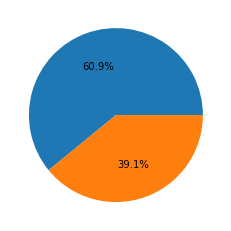

In [331]:
pie_plot(arr,labels=['member','casual'])

In [258]:
casual=casual.drop(casual[casual['diff']>26].index)

In [418]:
labels=['0-10','10-30','30-60','60-max']
label_1=['0-30','30-60','60-max']

#### *Casuals ride preferences*

In [390]:
casual['diff']=casual['diff']*60

In [419]:
casual['mins']=pd.cut(x=casual['diff'],bins=[0,10,30,60,casual['diff'].max()],labels=labels)

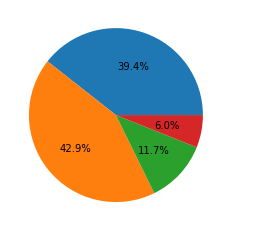

In [420]:
pie_plot(casual['mins'].value_counts(sort=False),labels=labels)

In [393]:
casual['mins']=pd.cut(x=casual['diff'],bins=[0,30,60,casual['diff'].max()],labels=label_1)

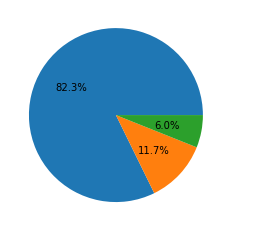

In [394]:
pie_plot(casual['mins'].value_counts(sort=False),label_1)

#### *checking for overall rider preference to check pattern certainity*

In [395]:
member['diff']=member['diff']*60

In [396]:
member['mins']=pd.cut(x=member['diff'],bins=[0,30,60,member['diff'].max()],labels=label_1)

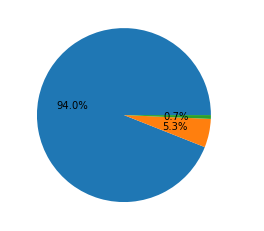

In [397]:
pie_plot(member['mins'].value_counts(sort=False),label_1)

In [398]:
new=req_data[['member_casual','diff']]

In [399]:
new['diff']=new['diff']*60

In [405]:
new['mins']=pd.cut(new['diff'],bins=[0,30,60,new['diff'].max()],labels=label_1)

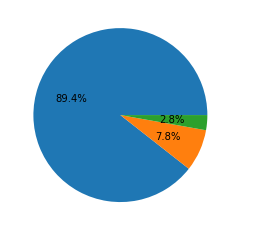

In [406]:
pie_plot(new['mins'].value_counts(sort=False),label_1)

### *popular stations for casuals*

In [473]:
check_0=data_0[['member_casual','diff','start_station_name','end_station_name']]
check_1=data_1[['member_casual','diff','start_station_name','end_station_name']]
check_2=data_2[['member_casual','diff','start_station_name','end_station_name']]

In [474]:
req_data_1=pd.concat([check_0,check_1,check_2])

In [485]:
req_data_1.shape
req_data_1=req_data_1.dropna(how='any')

In [676]:
casual_1=req_data_1[req_data_1['member_casual']=='casual']

In [679]:
start_station=casual_1.groupby(['start_station_name']).member_casual.count().nlargest(10).reset_index()

In [681]:
end_station=casual_1.groupby(['end_station_name']).member_casual.count().nlargest(10)

In [682]:
all_station=start_station.merge(end_station,left_on='start_station_name',right_on='end_station_name',how='inner')

In [684]:
all_station['casual']=all_station['member_casual_x']+all_station['member_casual_y']
all_station=all_station.drop(columns=['member_casual_x','member_casual_y'])

<AxesSubplot:xlabel='start_station_name'>

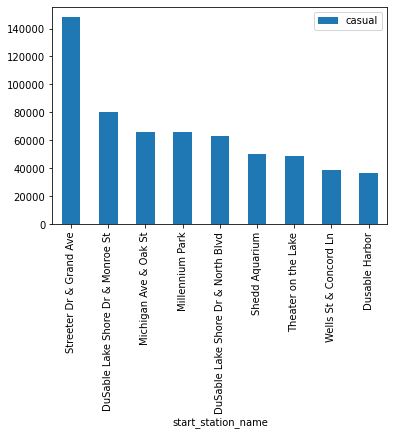

In [688]:
all_station.plot.bar(x='start_station_name',y='casual')

### *Popular bike type*

In [691]:
check_0=data_0[['member_casual','rideable_type']]
check_1=data_1[['member_casual','rideable_type']]
check_2=data_2[['member_casual','rideable_type']]

In [692]:
req_data_2=pd.concat([check_0,check_1,check_2])

In [696]:
bike=req_data_2.groupby('member_casual')['rideable_type'].value_counts().unstack().reset_index()

<AxesSubplot:xlabel='member_casual'>

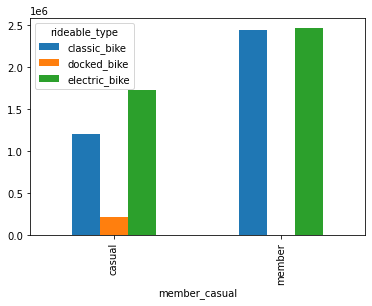

In [705]:
bike.plot.bar(x='member_casual')

<AxesSubplot:xlabel='start_lat', ylabel='start_lng'>

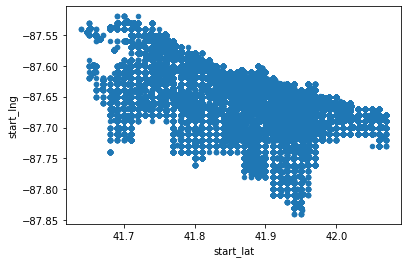

In [18]:
data_1.plot.scatter(x='start_lat',y='start_lng')